# Student Performance Prediction

## Final Machine Learning Project

This notebook predicts student final grade (`G3`) and analyzes the effects of study time, family background, and social activities on education outcomes.

### Project goals
- Build a regression model for student performance
- Compare multiple machine learning models
- Interpret environmental and social factors
- Compare a full model with a policy-focused model that removes previous grades (`G1`, `G2`)


## 1. Import libraries and project modules

In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")

from data_loader import load_student_data
from train import run_experiment
from evaluate import permutation_importance_df
from visualize import (
    ensure_dir,
    plot_grade_distribution,
    plot_correlation_heatmap,
    boxplot_feature_vs_grade,
    plot_model_comparison,
    plot_residuals,
    plot_top_features
)

pd.set_option("display.max_columns", 100)

## 2. Load dataset

In [ ]:
df = load_student_data(subject="mat", data_dir="../data")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (649, 31)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,13


## 3. Dataset overview and data quality checks

In [3]:
print(df.info())
print("\nMissing values by column:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe(include="all").T.head(25))

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

,missing_count
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0



Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,649,2,GP,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,649,2,F,383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,649.0,NaN,NaN,NaN,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
address,649,2,U,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,649,2,GT3,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,649,2,T,569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,649.0,NaN,NaN,NaN,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,NaN,NaN,NaN,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
Mjob,649,5,other,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,649,5,other,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Exploratory Data Analysis (EDA)

We focus especially on:
- Study time
- Family background
- Social activities
- Attendance and related environmental factors


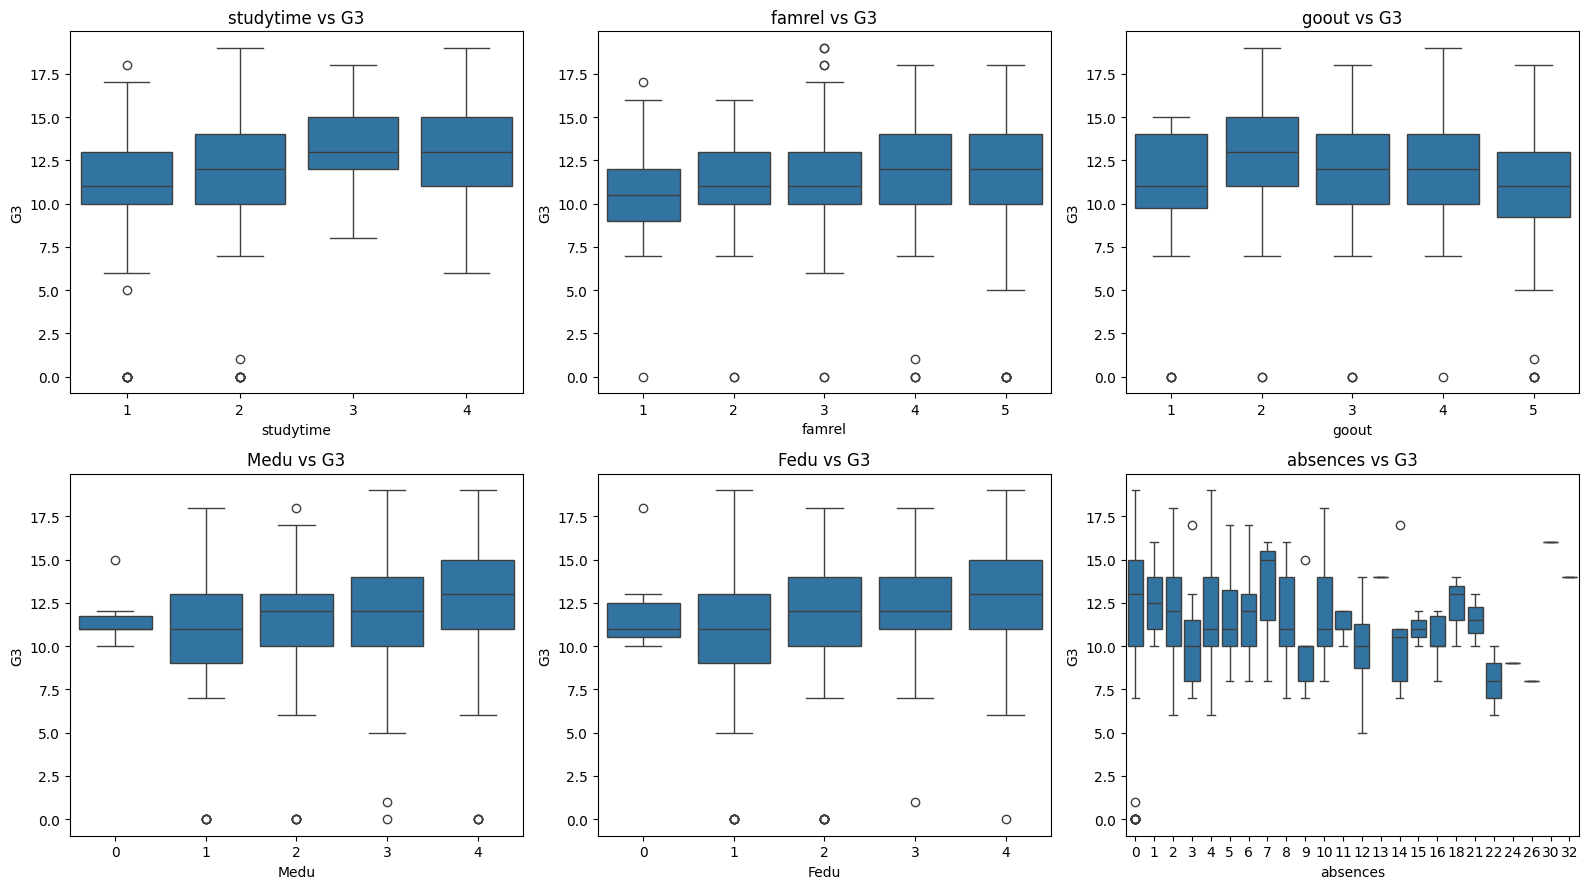

In [4]:
ensure_dir("../outputs/figures")
ensure_dir("../outputs/metrics")

plot_grade_distribution(df, "../outputs/figures/grade_distribution.png")
plot_correlation_heatmap(df, "../outputs/figures/corr_heatmap.png")

important_features = ["studytime", "famrel", "goout", "Medu", "Fedu", "absences"]
for feature in important_features:
    if feature in df.columns:
        plot_feature_path = f"../outputs/figures/{feature}_vs_g3.png"
        boxplot_feature_vs_grade(df, feature, plot_feature_path)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, feature in enumerate(important_features):
    if feature in df.columns:
        sns.boxplot(data=df, x=feature, y="G3", ax=axes[i])
        axes[i].set_title(f"{feature} vs G3")

plt.tight_layout()
plt.show()

In [5]:
# Grouped means for interpretation
group_features = ["studytime", "goout", "famrel", "Medu", "Fedu", "activities", "internet", "absences"]

for col in group_features:
    if col in df.columns:
        print(f"\nAverage G3 by {col}")
        display(df.groupby(col)["G3"].mean().sort_index().to_frame("avg_G3"))


Average G3 by studytime


,avg_G3
studytime,
1,10.844340
2,12.091803
3,13.226804
4,13.057143



Average G3 by goout


,avg_G3
goout,
1,10.729167
2,12.668966
3,12.151220
4,11.971631
5,10.872727



Average G3 by famrel


...

,avg_G3
activities,
no,11.718563
yes,12.104762



Average G3 by internet


,avg_G3
internet,
no,11.026490
yes,12.172691



Average G3 by absences


,avg_G3
absences,
0,12.040984
1,12.416667
2,12.190909
3,10.428571
4,12.010753
5,11.750000
6,12.122449
7,13.000000
8,11.619048


## 5. Experiment A: Full model (includes G1 and G2)

This version usually performs better because earlier grades are very strong predictors of the final grade.


In [6]:
results_full, best_models_full, X_train_full, X_test_full, y_train_full, y_test_full = run_experiment(
    df, drop_previous_grades=False
)

display(results_full)

plot_model_comparison(results_full, "../outputs/figures/model_comparison_with_G1_G2.png")
best_model_name_full = results_full.iloc[0]["Model"]
best_model_full = best_models_full[best_model_name_full]
preds_full = best_model_full.predict(X_test_full)
plot_residuals(y_test_full, preds_full, "../outputs/figures/residual_plot_best_model_with_G1_G2.png")

print("Best full-model:", best_model_name_full)

,Model,Best Params,MAE,RMSE,R2
1,RandomForest,"{'model__max_depth': 10, 'model__min_samples_l...",2.024415,2.767445,0.214625
0,Ridge,{'model__alpha': 50.0},2.056061,2.788096,0.202861
2,GradientBoosting,"{'model__learning_rate': 0.05, 'model__max_dep...",2.077001,2.819241,0.184952


Best full-model: RandomForest


## 6. Experiment B: Policy-focused model (removes G1 and G2)

This version is more useful if the goal is to understand the role of environmental and social factors before final grades are already known.


In [7]:
results_policy, best_models_policy, X_train_policy, X_test_policy, y_train_policy, y_test_policy = run_experiment(
    df, drop_previous_grades=True
)

display(results_policy)

plot_model_comparison(results_policy, "../outputs/figures/model_comparison_without_G1_G2.png")
best_model_name_policy = results_policy.iloc[0]["Model"]
best_model_policy = best_models_policy[best_model_name_policy]
preds_policy = best_model_policy.predict(X_test_policy)
plot_residuals(y_test_policy, preds_policy, "../outputs/figures/residual_plot_best_model_without_G1_G2.png")

print("Best policy-focused model:", best_model_name_policy)

,Model,Best Params,MAE,RMSE,R2
1,RandomForest,"{'model__max_depth': 10, 'model__min_samples_l...",2.024415,2.767445,0.214625
0,Ridge,{'model__alpha': 50.0},2.056061,2.788096,0.202861
2,GradientBoosting,"{'model__learning_rate': 0.05, 'model__max_dep...",2.077001,2.819241,0.184952


Best policy-focused model: RandomForest


## 7. Feature importance for the policy-focused model

This is the most important interpretation step for the assignment because it shows which factors matter when previous grades are removed.


,feature,importance_mean,importance_std
14,failures,0.504650,0.167527
29,absences,0.075477,0.030590
20,higher,0.072600,0.032377
0,school,0.038246,0.026382
13,studytime,0.028448,0.015535
2,age,0.025875,0.008962
28,health,0.022023,0.016327
15,schoolsup,0.022014,0.023107
10,reason,0.020062,0.025992
1,sex,0.015401,0.006522


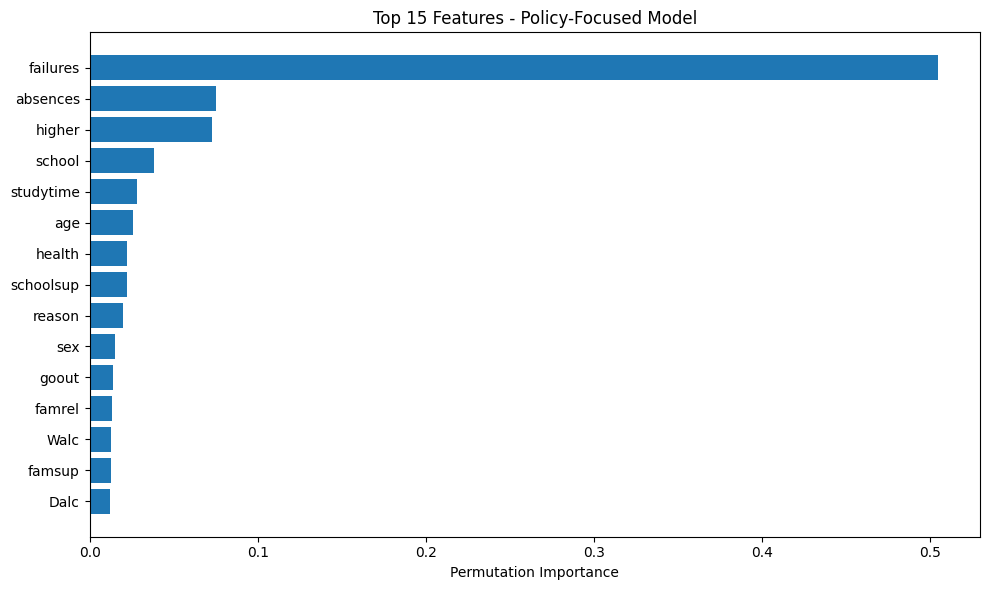

In [8]:
importance_df = permutation_importance_df(best_model_policy, X_test_policy, y_test_policy)
display(importance_df.head(20))

plot_top_features(importance_df, "../outputs/figures/feature_importance_policy_model.png", top_n=15)

plt.figure(figsize=(10, 6))
top_df = importance_df.head(15).iloc[::-1]
plt.barh(top_df["feature"], top_df["importance_mean"])
plt.title("Top 15 Features - Policy-Focused Model")
plt.xlabel("Permutation Importance")
plt.tight_layout()
plt.show()

## 8. Result interpretation guide

Use your actual outputs to write the discussion. Common interpretation points:

- If `studytime` is important, more study time is associated with better performance.
- If `Medu` and `Fedu` are important, family education level likely affects academic support and learning environment.
- If `goout`, `freetime`, or `activities` are important, social behavior influences school outcomes.
- If `absences` is important, attendance is a major academic factor.
- If the full model performs much better than the policy-focused model, previous grades dominate prediction.

This comparison is academically useful because it shows the difference between **pure prediction** and **meaningful educational analysis**.


## 9. conclusion
> The project shows that student performance can be predicted using machine learning, but the meaning of the prediction depends on which features are included. Models using previous grades usually perform best, while models without previous grades provide a better explanation of the effect of study time, family background, and social activities. This makes the policy-focused model more useful for early educational support and intervention.
